In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import math

#load the cleaned dataset
df = pd.read_csv('data/final_dataset.csv')
df['webTitle'] = df['webTitle'].str.lower()

## 1. Themes Analysis

### Section breakdown

In [6]:
#count articles by university and section
uni_section = pd.crosstab(df['university'], df['sectionName'])
uni_section

sectionName,Activate,Art and design,Australia news,Best of Birmingham,Best practice exchange,Books,Break into tech,Business,Business to business,Cardiff,...,Thinking about money,Travel,UK news,US news,Voluntary Sector Network,Wellness,Women in Leadership,Working in development,World news,Zurich School Competition
university,,,,,,,,,,,,,,,,,,,,,
Cardiff University,0,5,1,0,1,22,0,25,0,135,...,0,3,88,1,2,0,1,1,71,0
Imperial College London,0,17,4,0,0,26,1,67,0,0,...,0,1,75,19,1,0,2,3,608,1
London School of Economics,0,34,8,0,0,104,0,344,1,0,...,1,0,205,21,6,0,1,15,445,0
University College London,0,70,8,0,0,244,0,113,0,1,...,1,4,215,22,2,1,0,5,613,0
University of Birmingham,0,18,2,4,0,19,2,36,0,0,...,0,4,48,5,8,2,1,8,150,0
University of Bristol,0,9,3,0,0,21,0,20,0,0,...,0,1,72,6,3,0,0,2,190,0
University of Cambridge,2,30,10,0,0,43,0,57,2,0,...,0,1,91,19,2,1,2,1,286,0
University of Edinburgh,0,17,2,0,0,38,1,24,0,2,...,0,2,59,4,0,1,0,7,293,0
University of Manchester,0,32,3,0,0,51,0,51,0,1,...,0,8,117,6,1,0,0,5,107,0


### Creating bar chart breakdowns for individual universities

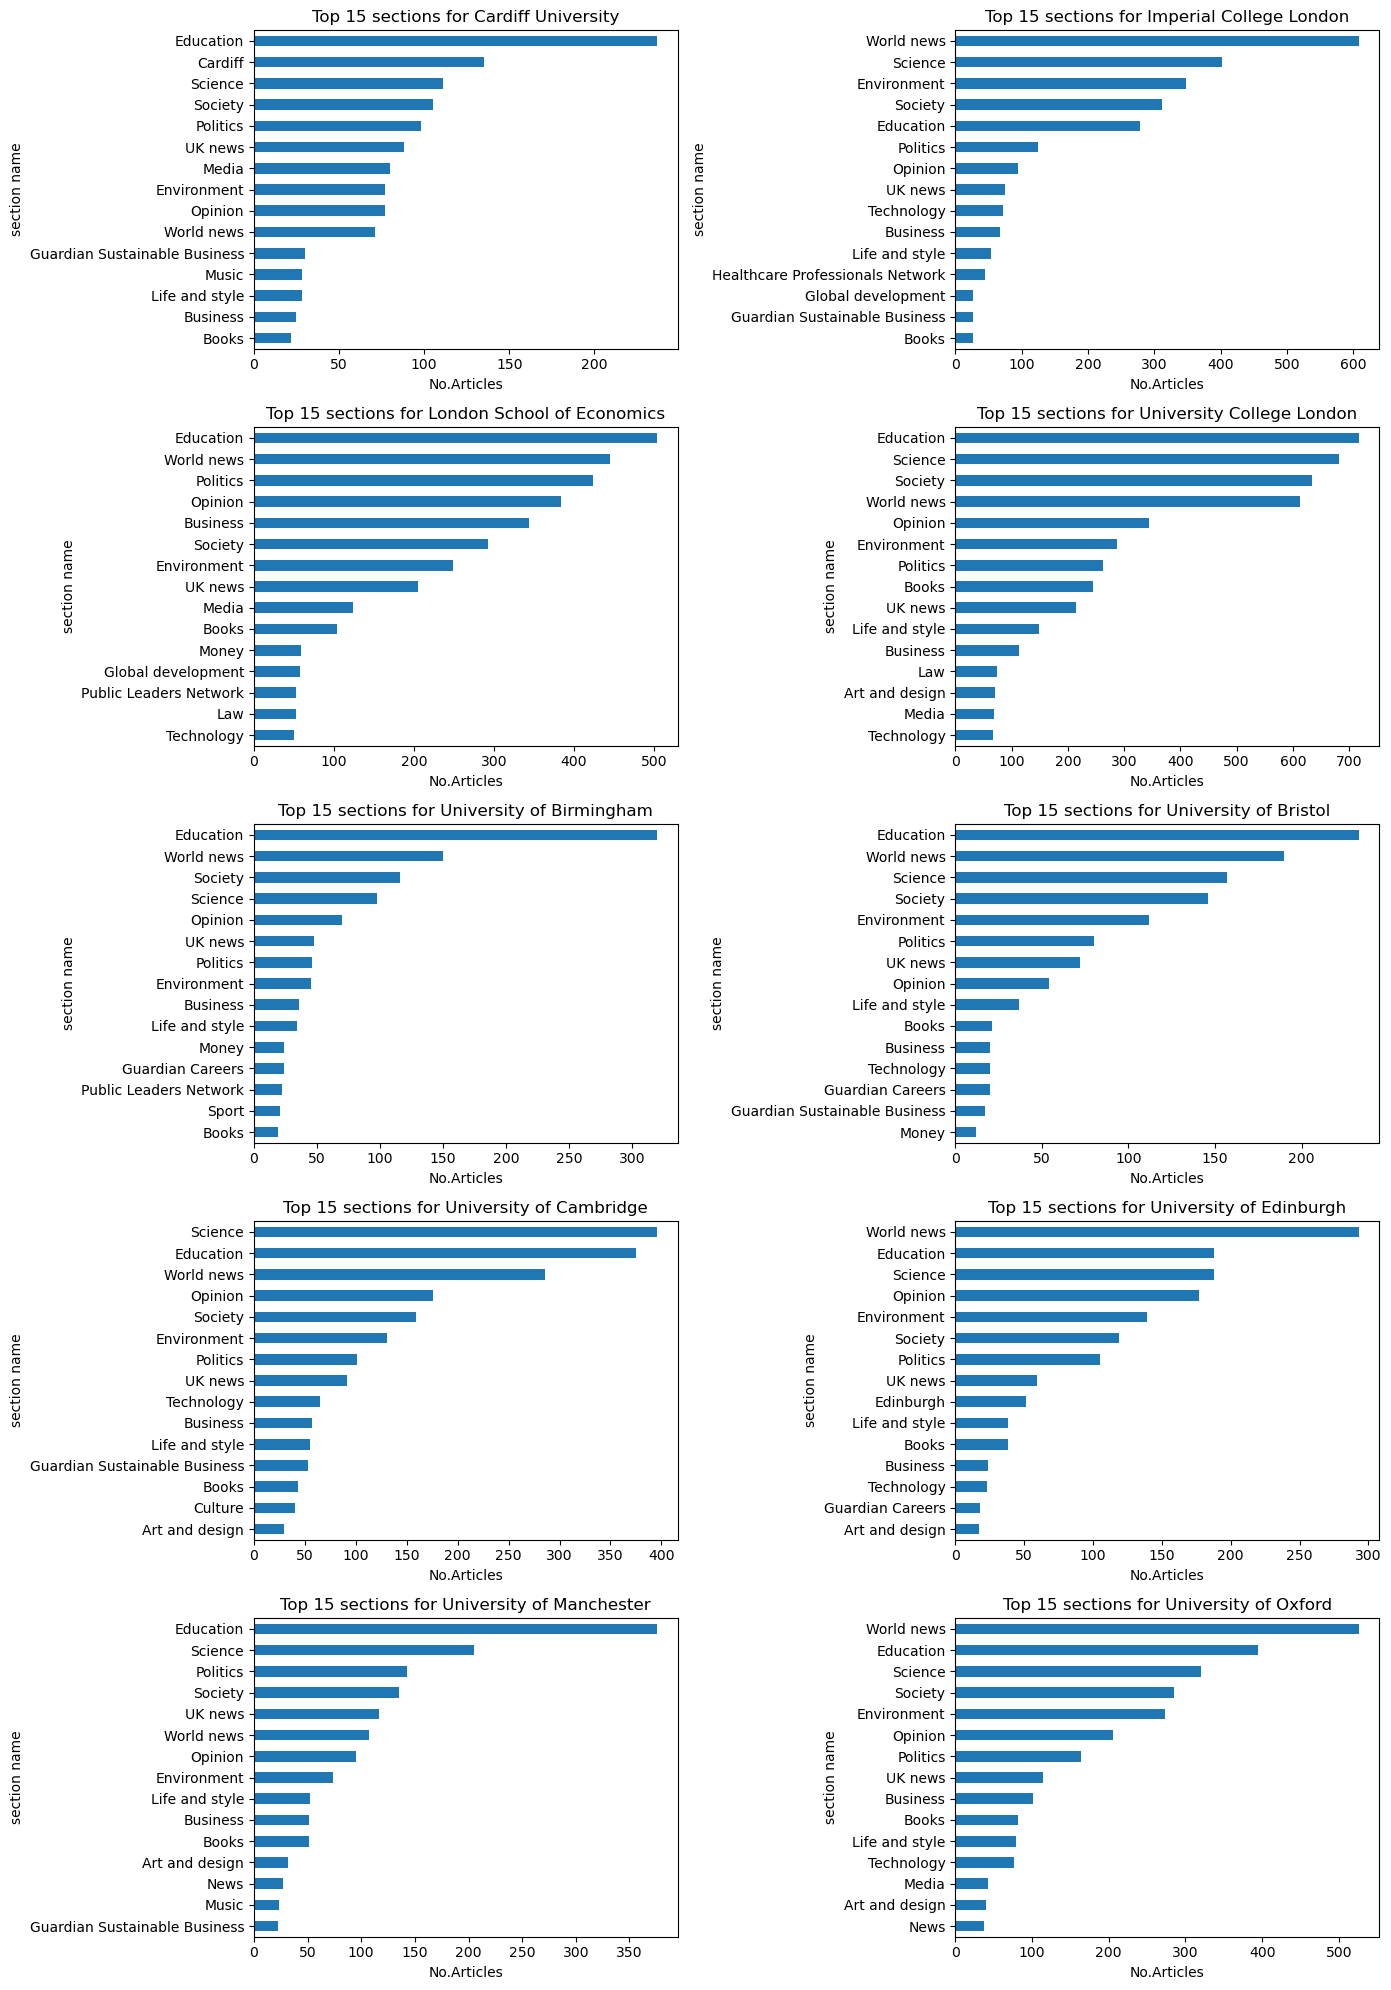

In [7]:
#putting bar charts side by side to visualise better
unis = uni_section.index

COLS = 2
rows = math.ceil(len(unis) / COLS)

fig, axes = plt.subplots(rows, COLS, figsize=(14, rows * 4))
axes = axes.flatten() 

for i, uni in enumerate(unis):
    data = uni_section.loc[uni]
    top15 = data.sort_values(ascending=False).head(15)

    top15.sort_values().plot(kind='barh', ax=axes[i])
    axes[i].set_title(f"Top 15 sections for {uni}")
    axes[i].set_xlabel("No.Articles")
    axes[i].set_ylabel("section name")

plt.tight_layout()
plt.show()

Across all ten universities, the most common sections covered are 'Education' and 'World news'. But looking at each of the individual bar charts, you can also see the individuality of each of the universities from some key differences.

Starting with LSE, after 'Education' and 'World news', the most covered sections are 'Politics', 'Opinion' and 'Business'. This aligns with what the university is known for - social science and the political relevance of its research output. Oxford and Cambridge appear frequently across a variety of sections, especially 'Science' and 'Society', separating them from specialist universities. Imperial College London is also a good example of a specialist university, being widely covered in 'Science', which shows it is known for its STEM courses. Universities such as Cardiff have a more even spread across fewer sections, which could possibly reflect a lower total article volume rather than focusing on what they are known for. 

These differences show that Guardian coverage of universities depends on each university's subject strengths and public reputation, not just on its size. 

### Section coverage and Article count per university

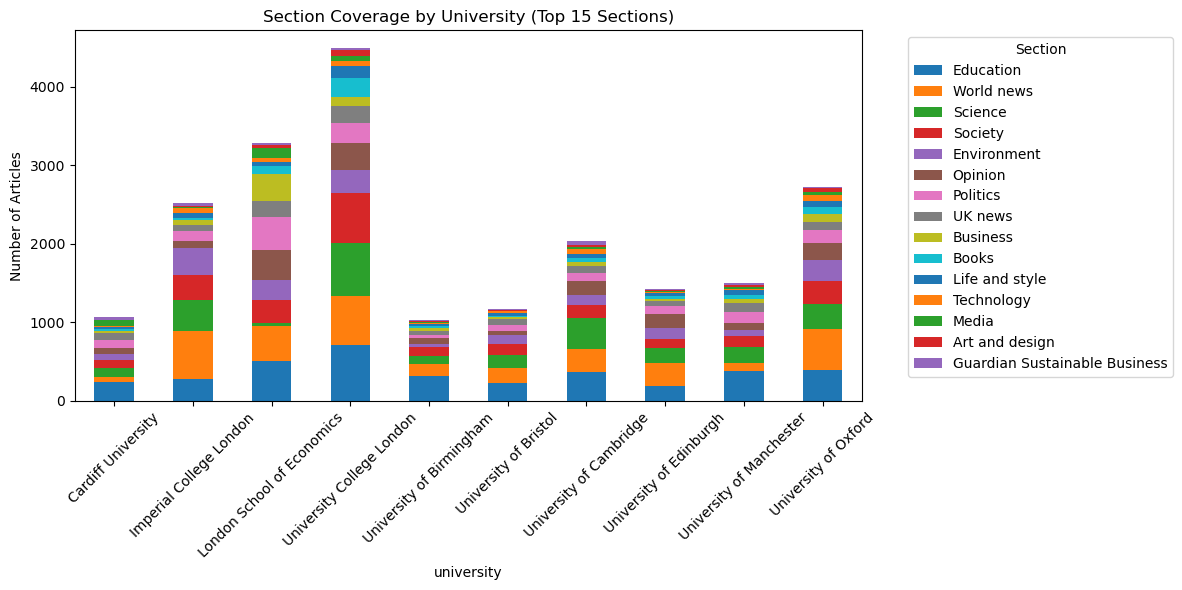

In [8]:
#need to put them all into one and colour coded so that it is easier to compare

top_sections = uni_section.sum().sort_values(ascending=False).head(15).index
filtered = uni_section[top_sections]

filtered.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Section Coverage by University (Top 15 Sections)")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.legend(title="Section", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

We decided to only use the top 15 sections for each university or else the data gets too much and there is not much useful analysis that can be done. 

When comparing all the universities simultaneously using a stacked chart, the majority of Articles covered for all of them are Education, World News and Science. It is also easier to see the difference in the number of raw articles produced for each university as well - UCL and LSE leading with the most articles written. Cardiff, Birmingham and Bristol have the lowest amount of articles, but it is still above 1000 per university. This means the universities with a lot more articles written can visually dominate the stacked chart. This means normalising the proportions is important to get a clearer overview, which we have done next. 

Sections where all universities have >20 articles: 9
['Education', 'Environment', 'Life and style', 'Opinion', 'Politics', 'Science', 'Society', 'UK news', 'World news']


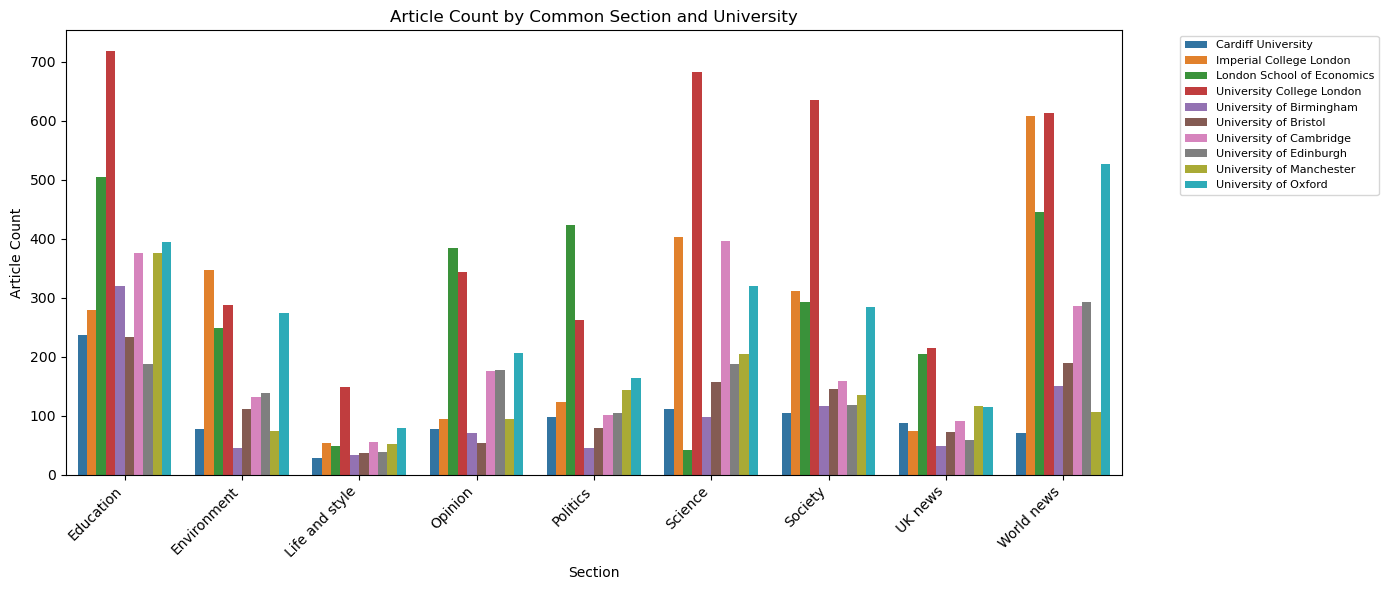

In [9]:
# categorising further so it is only section names all the universities have in common and only the ones with more than 20 articles each
common_section_names = uni_section.columns[uni_section.min(axis=0) > 20].tolist()
print(f"Sections where all universities have >20 articles: {len(common_section_names)}")
print(common_section_names)
common = uni_section[common_section_names]


common_reset = common.reset_index()
common_melted = common_reset.melt(id_vars='university', var_name='Section', value_name='Article Count')

plt.figure(figsize=(14, 6))
sns.barplot(data=common_melted, x='Section', y='Article Count', hue='university')
plt.title('Article Count by Common Section and University')
plt.xlabel('Section')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

The stacked chart showed 15 sections for each of the universities, which made it difficult to compare the individual sections covered by the universities. So instead, we filtered the data to show sections where each university has more than at least 20 articles and then filtered further so that only the sections all ten universities had in common were shown in the bar chart. This narrowed it down to nine sections. Plotting the bars for all the universities for each section side by side makes it more visually pleasing as well as easier to compare.

The short list of sections shows how uneven cross-university coverage is (few themes generate substantial coverage across all ten), and the fact that most sections are dominated by a few universities. This matters methodologically — it means simple section comparisons risk reflecting the Guardian's editorial emphasis on particular universities rather than genuine thematic differences.

## 2. Keyword Frequency Analysis

Our research questions ask about politics vs education vs events, the differences between universities and spikes around major events such as COVID-19. So we picked a keyword set that relates to these individual themes and stored it in a dictionary mapping keyword lists to category names.

In [14]:
#keyword dictionary to find in titles
keywords = {
    "tuition_fees": ["tuition", "fees", "student debt", "budget"],
    "research": ["research", "study", "scientists", "discovery"],
    "rankings": ["ranking", "ranked", "top university", "league table"],
    "politics": ["government", "policy", "minister", "brexit", "regulation"],
    "covid": ["covid", "pandemic", "lockdown", "coronavirus"],
    "strike": ["strike", "union", "walkout", "industrial action"],
    "international": ["international", "overseas", "visa", "foreign students", "immigration"],
    "funding": ["funding", "investment", "cuts"]
}

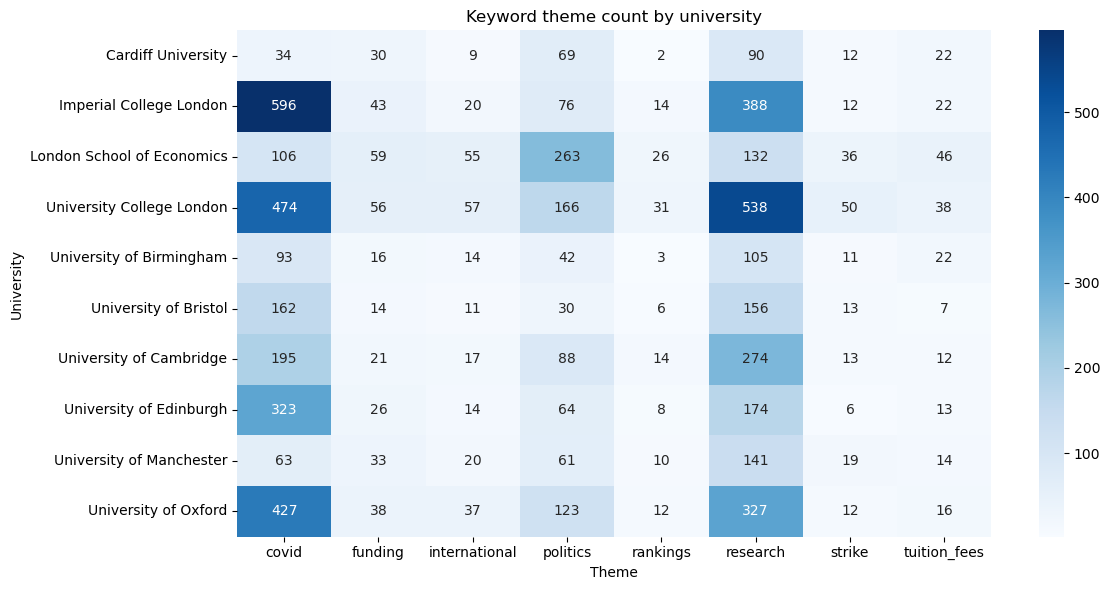

In [15]:
results = []

for uni in df['university'].unique():
    subset = df[df['university'] == uni]
    
    for category, words in keywords.items():
        # join keywords with | so str.contains matches any of them
        pattern = "|".join(words)
        count = subset['webTitle'].str.contains(pattern, case=False, na=False).sum()
        results.append({
            "university": uni,
            "category": category,
            "count": count
        })

keyword_df = pd.DataFrame(results) #storing in data frame

#keyword raw count heatmap

keyword_pivot = keyword_df.pivot(
    index='university',
    columns='category',
    values='count'
).fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(keyword_pivot, annot=True, cmap="Blues", fmt=".0f")
plt.title("Keyword theme count by university")
plt.ylabel("University")
plt.xlabel("Theme")
plt.tight_layout()
plt.show()

We used a raw keyword counts heatmap to see the actual number of times a keyword appeared in the web title for a university article. From the heatmap, you can see that LSE and UCL have the highest keyword match for most of the themes. This is consistent with their high total article volume. The research category generates the most overall matches, which makes sense as the Guardian frequently mentions the research output of universities. In the international theme, LSE and UCL dominate, which reflects their large international student population and global research profiles. 

However, raw counts alone can be misleading (universities with more articles will score more), which is why the normalised view of the heatmap has been created below. 

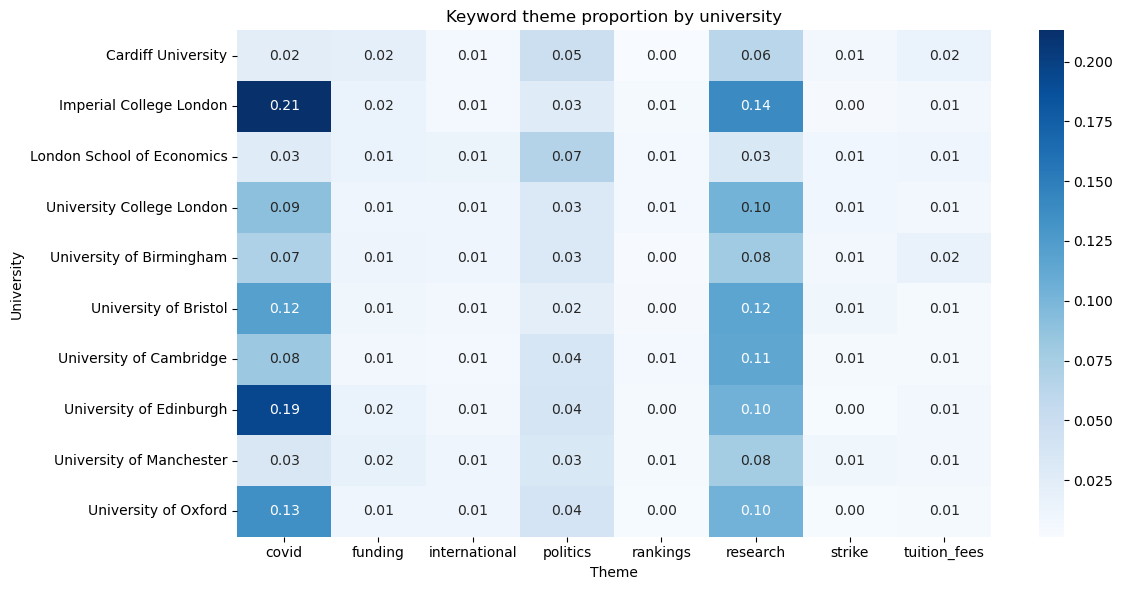

In [16]:
#normalised heatmap 
total_articles = df['university'].value_counts()
keyword_pivot_norm = keyword_pivot.div(total_articles, axis=0)

plt.figure(figsize=(12, 6))
sns.heatmap(keyword_pivot_norm, annot=True, cmap="Blues", fmt=".2f")
plt.title("Keyword theme proportion by university")
plt.ylabel("University")
plt.xlabel("Theme")
plt.tight_layout()
plt.show()

After normalising the keyword proportion (keyword count/total articles for the university), we can compare the themes more objectively between universities. 

We can see that LSE has a much larger proportion of articles under the theme of politics compared to other universities, which aligns with its reputation of being a university of social science and the frequent citation of LSE academics in political commentary. 
Imperial shows a higher proportion of research articles. You can see the absolute value after normalisation shows Imperial University's prominence in this theme, because with the raw count, it seemed like UCL dominated this section, but with the normalised heatmap, you can see this is not the case. 
Cardiff and Birmingham were two that had the lowest raw article count, but despite this, the normalised heatmap shows proportions broadly comparable to Oxford and Cambridge in many categories, suggesting coverage is thematically similar between these universities. 
The funding and tuition fees themes are almost equally spread between the universities, meaning they aren't associated with any one institution, just a wide spread category which is common to all the universities. 
Overall, the Guardian coverage reflects institutional identity - specialist universities such as LSE and Imperial have specific themes related to them compared to generalist universities. 

One of our research questions is 'How does coverage spike around major UK events?'. The keyword frequency heatmaps show that COVID-related keywords account for a large share of headline matches across most universities, suggesting that the pandemic generated substantial coverage. However, these heatmaps show aggregate counts over the full 2010–2024 period and cannot tell us when the spike occurred. The time-series analysis in the next section examines this directly by plotting article counts over time and overlaying major events.

### Explanatory visuals

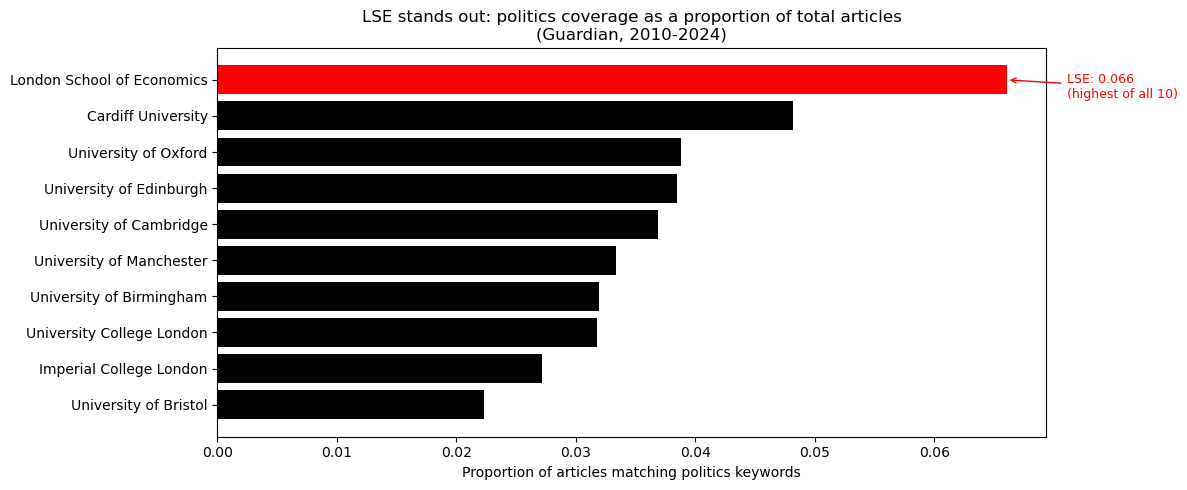

In [17]:
#explanatory plot: LSE's disproportional coverage in politics theme
fig, ax = plt.subplots(figsize=(12, 5))

politics_data = keyword_pivot_norm['politics'].sort_values(ascending=True)

#highlight LSE in red
colours = []
for uni in politics_data.index:
    if uni == 'London School of Economics':
        colours.append('red')
    else:
        colours.append('black')

ax.barh(politics_data.index, politics_data.values, color=colours)

#annotate LSE bar
lse_val = politics_data['London School of Economics']
lse_pos = list(politics_data.index).index('London School of Economics')
ax.annotate(
    f'LSE: {lse_val:.3f}\n(highest of all 10)',
    xy=(lse_val, lse_pos),
    xytext=(lse_val + 0.005, lse_pos - 0.5),
    fontsize=9,
    color='red',
    arrowprops=dict(arrowstyle='->', color='red')
)

ax.set_xlabel('Proportion of articles matching politics keywords')
ax.set_title('LSE stands out: politics coverage as a proportion of total articles\n(Guardian, 2010-2024)')
plt.tight_layout()
plt.show()

From this chart, you can see that LSE has a much higher share of politics-related headlines than any other Russell Group university. This is a clear reflection of LSE's reputation as the UK's leading social science institution. All other universities cluster between 2-4%, while LSE is above 6%. This finding holds after normalising for total article volume, confirming it is not an artefact of LSE's overall coverage level.

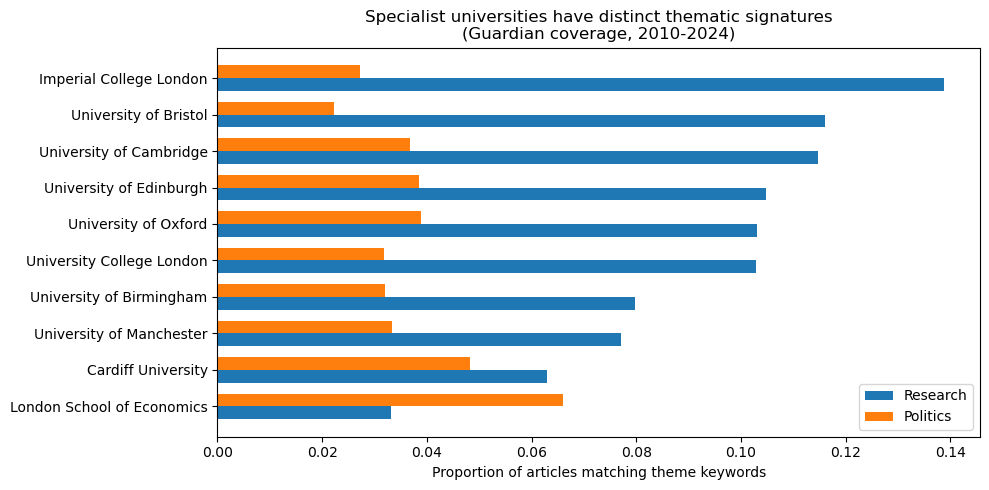

In [19]:
#explanatory plot: comparing research vs politics themes across universities
fig, ax = plt.subplots(figsize=(10, 5))

compare = keyword_pivot_norm[['research', 'politics']].copy()
compare = compare.sort_values('research', ascending=True)

x = range(len(compare))
bar_width = 0.35

ax.barh([i - bar_width/2 for i in x], compare['research'], bar_width, label='Research')
ax.barh([i + bar_width/2 for i in x], compare['politics'], bar_width, label='Politics')

ax.set_yticks(list(x))
ax.set_yticklabels(compare.index)
ax.set_xlabel('Proportion of articles matching theme keywords')
ax.set_title('Specialist universities have distinct thematic signatures\n(Guardian coverage, 2010-2024)')
ax.legend()

plt.tight_layout()
plt.show()

This chart directly compares the research and politics keyword proportions across all 10 universities. The contrast between Imperial (highest research proportion) and LSE (highest politics proportion) illustrates how specialist universities receive coverage that reflects their institutional identity. Generalist universities like Oxford and Cambridge sit in the middle on both themes, consistent with their broader academic scope.

## 3. Conclusion

### Summary of findings

This project analysed Guardian newspaper coverage of 10 Russell Group universities between 2010 and 2024. We used a dataset of 25,142 articles and examined three research questions. 

#### 1. Which universities receive the most coverage, and how has this changed over time?

In terms of raw article counts, UCL received the most coverage (5,227 articles), followed by LSE (3,980) and Oxford (3,170). Cardiff and Bristol received substantially less coverage than the London-based institutions.

From an initial inspection of the data, the number of articles varies over time rather than following a consistent upward or downward trend. There is a noticeable increase in coverage around 2020–2021, followed by a decline in later years. This suggests that media attention towards universities fluctuates and may be influenced by external factors or specific periods of heightened interest, rather than exhibiting a stable long-term pattern.

#### 2. What themes dominate coverage, and do they differ across institutions?

Sectional-level analysis shows that 'Education' and 'World news' are the dominant categories across all ten universities. However, thematic signatures differ significantly between different universities, depending mostly on whether the institution is specialised or generalised and the total raw number of articles each university has. After normalising for total article volume, LSE clearly has a disproportionately high number of articles related to politics, and Imperial is associated more with research and science themes. The keyword analysis confirms these patterns at the headline level: LSE's politics proportion is the highest of all 10 universities, and Imperial's research proportion is much higher compared to its politics proportion. These differences are consistent with each university's subject specialisation. 

#### 3. How does coverage spike around major UK events?

The keyword frequency heatmaps show that COVID-related terms account for a large proportion of headline matches across almost all universities, indicating that the pandemic was a major driver of university-related coverage. However, the heatmaps alone cannot identify when these spikes occurred. The time-series analysis (Section X) addresses this directly, showing that the 2020–2021 spike in total article counts coincides with the COVID-19 pandemic, and that this pattern is consistent across most universities. The strike and funding themes show comparatively little variation, suggesting that not all major events generate the same level of media response.

### Limitations

Some of the limitations of our project include:
- Our keyword analysis relies on matching terms in article titles only. Headlines are often brief and may not reflect the full content of an article — a piece primarily about student mental health might not use any of our keyword terms in its title. This likely underestimates coverage of some themes.
- As identified in the IDA stage, 21.5% of articles appear under multiple universities. This means per-university keyword counts may include articles that are not primarily about that institution but mention it alongside others.
- Our keyword categories are manually defined and may not capture all relevant terms. For example, the "politics" category includes "brexit" and "minister" but may miss articles framed around "parliament" or "legislation".
- The Guardian is a single news source with its own editorial perspective. Coverage patterns may differ in other outlets, so our findings reflect how the Guardian covers universities, not media coverage in general.

### Suggestions for future work

- Analyse the full body text of articles rather than just headlines, which would give a more complete picture of thematic coverage. The bodyText data was collected but excluded from the CSV due to file size — it can be reproduced by re-running data_collection.ipynb.
- Apply natural language processing techniques such as topic modelling to identify themes in article text without relying on predefined keyword lists.
- Compare coverage across multiple UK newspapers (e.g. Guardian vs Telegraph) to examine whether political leaning of the outlet affects how universities are portrayed.
- Incorporate article engagement data (e.g. comment counts, shares) if available, to assess not just what is covered but what generates public discussion.